In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [2]:
df = pd.read_csv("../data/raw/addiction_data.csv")

In [3]:
df.dropna(inplace=True)

In [4]:
df.drop(columns = ['addicted_label','transaction_id','user_id'], inplace=True)

In [5]:
df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe
5,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe
6,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe


In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]


<class 'pandas.core.series.Series'>
Index: 6681 entries, 2 to 7499
Series name: addiction_level
Non-Null Count  Dtype 
--------------  ----- 
6681 non-null   object
dtypes: object(1)
memory usage: 104.4+ KB


In [7]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42, stratify = y)

In [8]:
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
quantile_cols = X_train.select_dtypes(include='number').columns.difference(['age']).tolist()

In [9]:
categorical_cols

['gender', 'stress_level', 'academic_work_impact']

In [10]:
quantile_cols

['app_opens_per_day',
 'daily_screen_time_hours',
 'gaming_hours',
 'notifications_per_day',
 'sleep_hours',
 'social_media_hours',
 'weekend_screen_time',
 'work_study_hours']

In [11]:
preprocessor = ColumnTransformer(
    transformers = [
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('quantile',QuantileTransformer(output_distribution='normal',random_state=42), quantile_cols),
        ('age_scaler', StandardScaler(), ['age'])

    ]
)

In [12]:
preprocessor

,transformers,"[('onehot', ...), ('quantile', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [13]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': '4'}>, <Axes: title={'center': '5'}>,
        <Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>],
       [<Axes: title={'center': '8'}>, <Axes: title={'center': '9'}>,
        <Axes: title={'center': '10'}>, <Axes: title={'center': '11'}>],
       [<Axes: title={'center': '12'}>, <Axes: title={'center': '13'}>,
        <Axes: title={'center': '14'}>, <Axes: title={'center': '15'}>],
       [<Axes: title={'center': '16'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

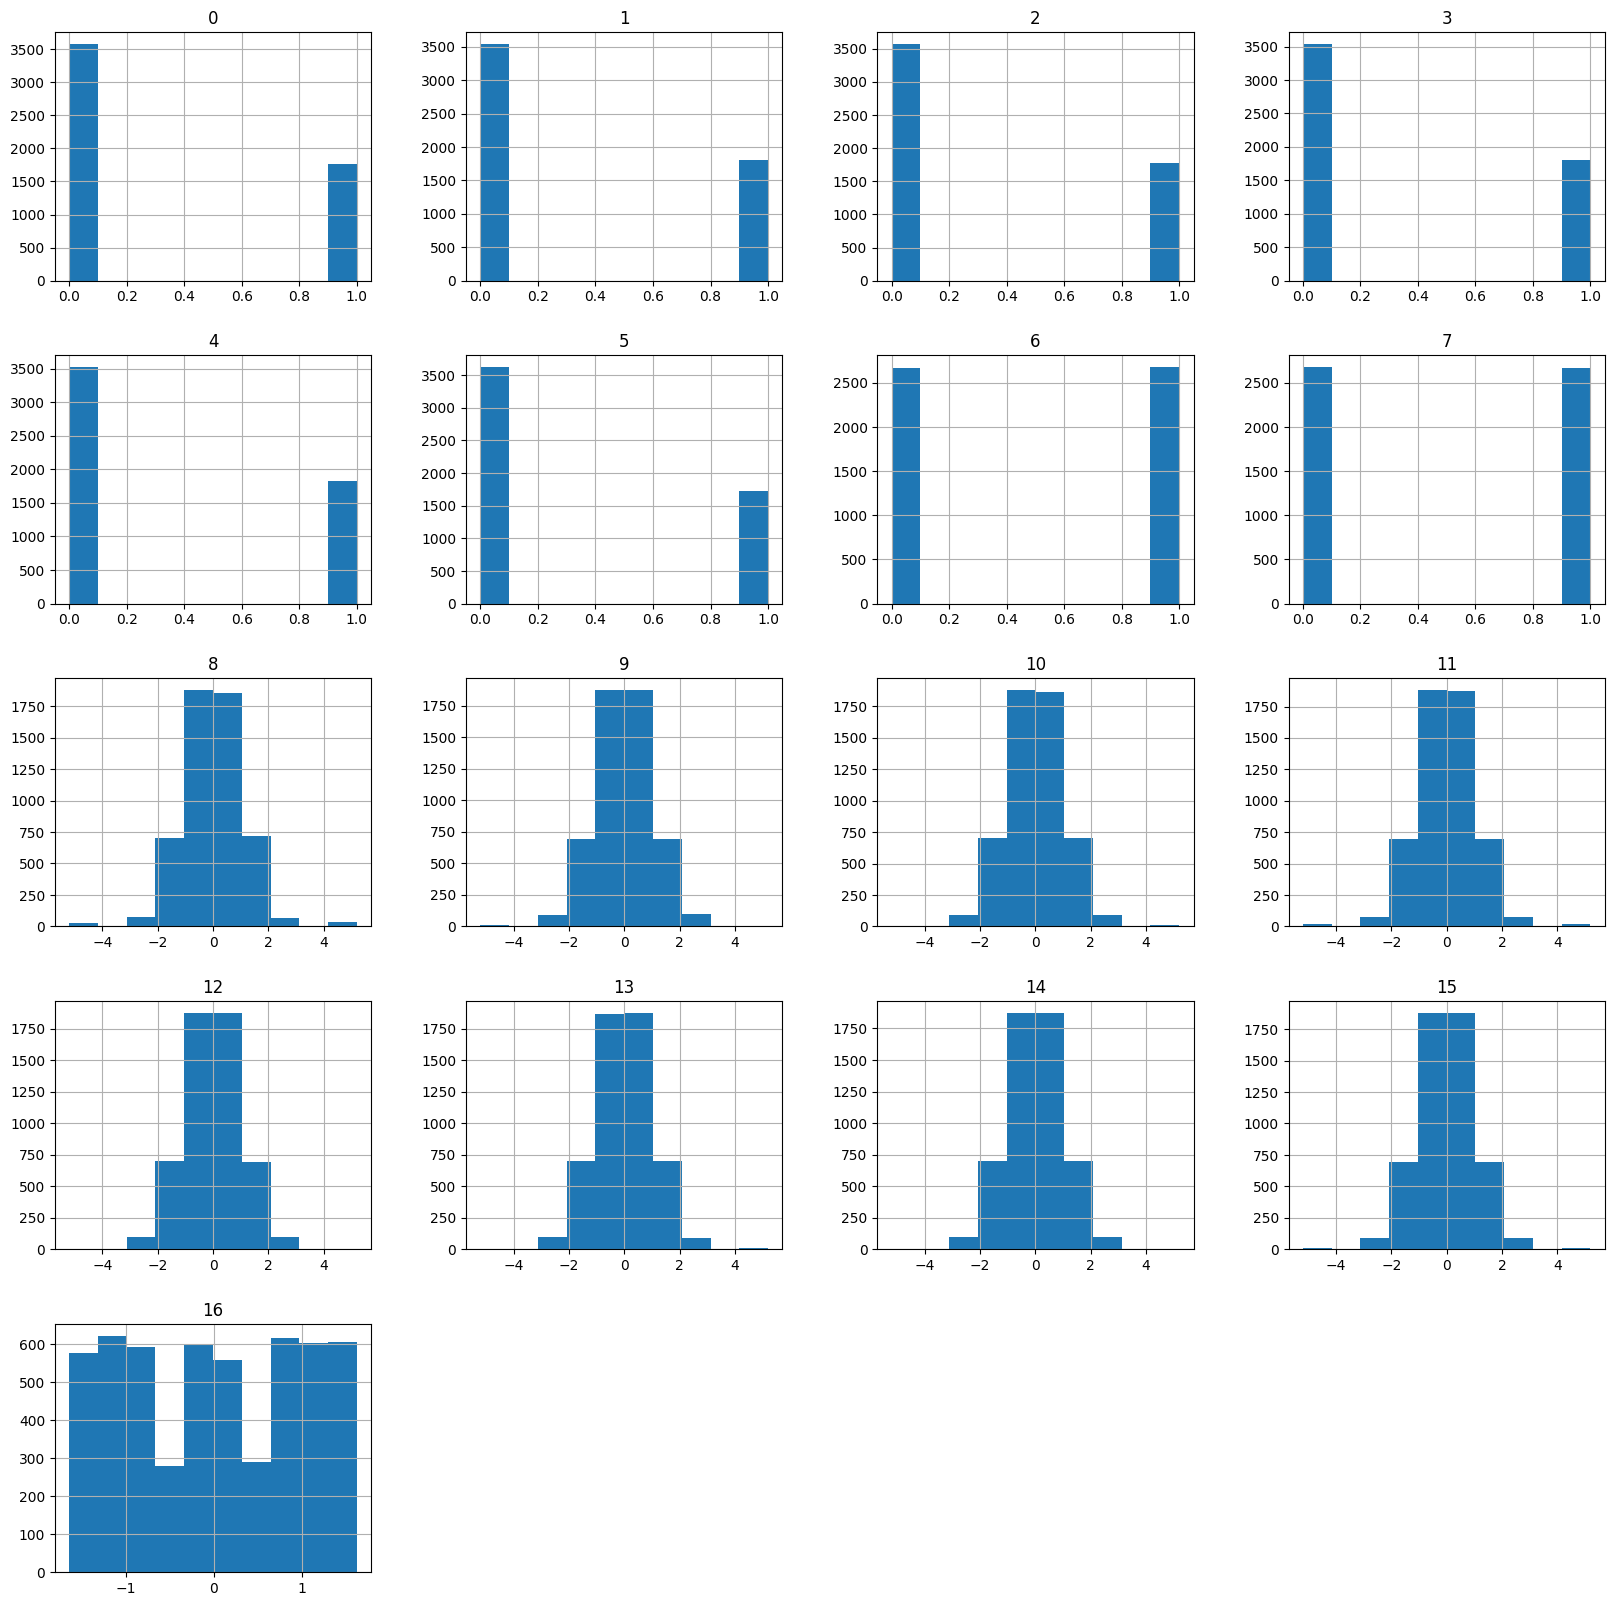

In [14]:
pd.DataFrame(X_train_processed).hist(figsize=(20,20))

### Encoding target

In [15]:
le = LabelEncoder()

In [16]:
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

### Saving Processed Data and preprocessor.

In [17]:
pd.DataFrame(X_train_processed).to_csv('../data/processed/X_train_processed.csv',index=False)
pd.DataFrame(y_train_encoded).to_csv('../data/processed/y_train_encoded.csv',index=False)
pd.DataFrame(X_test_processed).to_csv('../data/processed/X_test_processed.csv',index=False)
pd.DataFrame(y_test_encoded).to_csv('../data/processed/y_test_encoded.csv',index=False)





In [18]:
joblib.dump(preprocessor,'../ml/preprocessor/preprocessor.joblib')

['../ml/preprocessor/preprocessor.joblib']

In [19]:
pd.DataFrame(X_train_processed).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.664082,1.597698,-0.447305,1.615945,0.661162,-0.555462,0.963423,-0.908975,0.088339
1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,-0.094232,-0.500651,-1.721914,0.128317,0.134645,-0.403356,-0.623372,-1.123415,0.856270
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-1.027247,-1.368450,0.427976,-0.506348,-2.169694,-0.227777,-0.912528,0.092972,0.664287
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.168912,-0.442811,1.121060,1.128144,0.080379,0.101796,-0.721714,-0.754664,-0.679591
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,-2.386340,-0.922330,0.668987,-0.537980,-0.065284,-0.227777,-0.761353,-0.461215,-1.255539
